In [96]:
import pandas as pd

数据来源文件读取

In [97]:
happiness = pd.read_csv("../data/happiness.csv")
income = pd.read_csv("../data/income.csv")
house = pd.read_csv("../data/house_price.csv")
province = pd.read_csv("../data/province.csv")
location = pd.read_csv("../data/location.csv")

happiness.head()

,city,happiness
0,Beijing,91.61
1,Shanghai,95.00
2,Tianjin,65.56
3,Chongqing,68.63
4,Guangzhou,82.16


查看数据规模

In [98]:
df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
    .merge(province, on="city")
    .merge(location, on="city")
)

print(f"数据集大小：{df.shape[0]} 行 × {df.shape[1]} 列")

df.head()

数据集大小：1830 行 × 7 列


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


显示数据类型

In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1830 entries, 0 to 1829
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         1830 non-null   str    
 1   happiness    1830 non-null   float64
 2   income       1830 non-null   int64  
 3   house_price  1830 non-null   int64  
 4   province     1830 non-null   str    
 5   longitude    1830 non-null   float64
 6   latitude     1830 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 130.2 KB


数据描述统计

In [100]:
df.describe().round(2)

,happiness,income,house_price,longitude,latitude
count,1830.00,1830.00,1830.00,1830.00,1830.00
mean,70.19,89432.92,12530.53,115.39,30.95
std,4.53,13103.37,5269.53,3.85,5.14
min,56.83,9800.00,7553.00,86.73,19.67
25%,66.85,82589.00,10739.00,113.16,27.63
50%,70.11,89893.00,12190.00,115.40,31.14
75%,73.02,97550.00,13536.00,118.43,32.75
max,95.00,203863.00,165000.00,126.90,46.62


缺失值检查

In [101]:
df = (
    happiness
    .merge(income, on="city")
    .merge(house, on="city")
    .merge(province, on="city")
    .merge(location, on="city")
)

print("Missing Values:")
print(df.isnull().sum())

df.head()

Missing Values:
city           0
happiness      0
income         0
house_price    0
province       0
longitude      0
latitude       0
dtype: int64


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


数据重复性检查

In [102]:
duplicates = df["city"].duplicated().sum()

print(f"Duplicate cities: {duplicates}")

df.head()

Duplicate cities: 1581


,city,happiness,income,house_price,province,longitude,latitude
0,Beijing,91.61,181438,48492,北京市,116.4074,39.9042
1,Shanghai,95.00,203863,61399,上海市,121.4737,31.2304
2,Tianjin,65.56,76008,11056,天津市,117.2000,39.1333
3,Chongqing,68.63,91580,11579,重庆市,106.5516,29.5630
4,Guangzhou,82.16,138320,39415,广东省,113.2644,23.1291


数据表合并(一开始没有province.csv和location.csv,所以我直接在这儿用了映射,但后来我在做geo地图时发现总这么映射太笨重了,徒费心力)

In [103]:
df = happiness.merge(income, on="city").merge(house, on="city").merge(province, on="city").merge(location, on="city")  # 五表合并

性价比指标计算和各省市数据平均值的聚合与重命名

In [104]:
import numpy as np

# 计算性价比指标
df['value_index'] = df['income'] / df['house_price']

# 按省份聚合平均值
province_summary = df.groupby('province', as_index=False).agg({
    'happiness': 'mean',
    'income': 'mean',
    'house_price': 'mean',
    'value_index': 'mean'
})
# 重命名列为平均值
province_summary = province_summary.rename(columns={
    'happiness': 'avg_happiness',
    'income': 'avg_income',
    'house_price': 'avg_house_price',
    'value_index': 'avg_value_index'
})
print("\n省级聚合样例：\n", province_summary.head(5), sep="")


省级聚合样例：
  province  avg_happiness     avg_income  avg_house_price  avg_value_index
0      上海市      95.000000  203863.000000     61399.000000         3.320298
1      云南省      69.970909   89588.909091     11387.909091         8.290937
2   内蒙古自治区      68.761429   95754.571429     12700.428571         7.592269
3      北京市      91.610000  181438.000000     48492.000000         3.741607
4      台湾省      81.800000   18500.000000     42000.000000         0.440476


住房可负担性指数排名前20的城市的数据显示

In [105]:
import pandas as pd

# 取 Top20
top20 = (
    df.sort_values("value_index", ascending=False)
      .head(20)
      .reset_index(drop=True)
)

top20

,city,happiness,income,house_price,province,longitude,latitude,value_index
0,Lijiang,70.49,104552,7553,云南省,103.4669,25.4659,13.842447
1,Zhangzhou,69.04,103668,7969,福建省,118.8747,26.8599,13.008910
2,Baicheng,70.60,103389,8110,吉林省,125.3567,44.6249,12.748335
3,Songyuan,68.94,106003,9179,吉林省,126.0722,44.0520,11.548426
4,Ezhou,64.25,108375,9559,湖北省,115.4542,30.9530,11.337483
5,Ezhou,64.25,108375,9559,湖北省,115.4542,30.9530,11.337483
6,Ezhou,64.25,108375,9559,湖北省,115.4542,30.9530,11.337483
7,Ezhou,66.73,108375,9559,湖北省,115.4542,30.9530,11.337483
8,Ezhou,66.73,108375,9559,湖北省,115.4542,30.9530,11.337483
9,Ezhou,66.73,108375,9559,湖北省,115.4542,30.9530,11.337483


全国300个主要城市的住房可负担性指数的柱状图分布分析

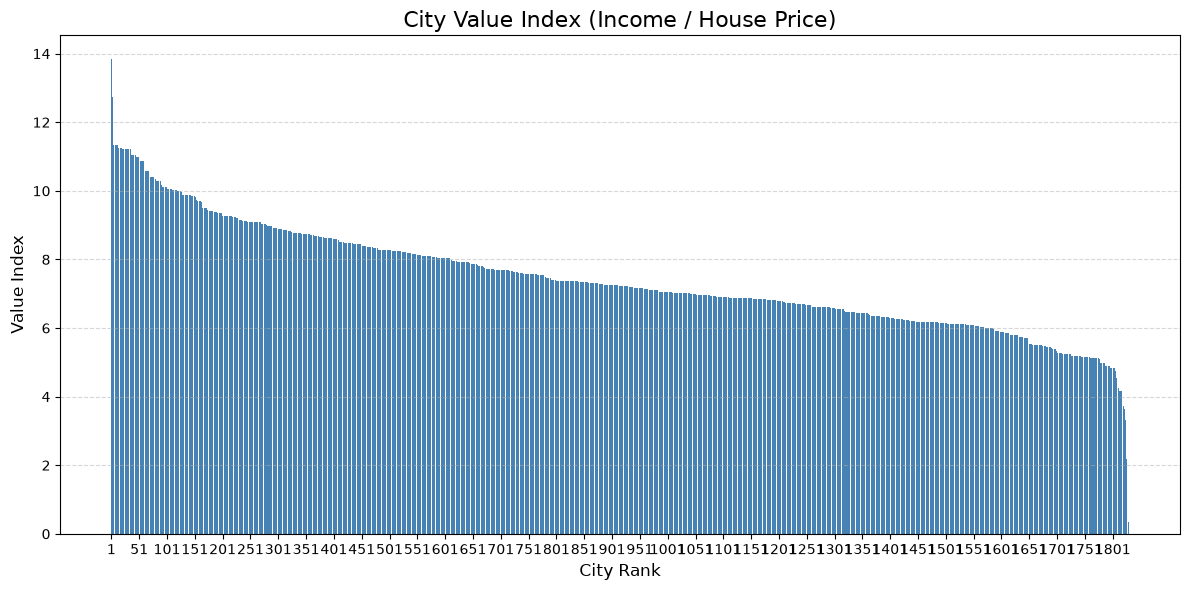

In [106]:
import matplotlib.pyplot as plt
import numpy as np
#按价值指数降序排序
top = df.sort_values("value_index", ascending=False).reset_index(drop=True)
#创建画布
fig, ax = plt.subplots(figsize=(12, 6))
#绘制柱状图
ax.bar(range(len(top)), top["value_index"], color="steelblue")
#每50个城市显示一个排名
step = 50
ticks = np.arange(0, len(top), step)

ax.set_xticks(ticks)
ax.set_xticklabels([str(i + 1) for i in ticks])
#设置标题和坐标轴标签
ax.set_title("City Value Index (Income / House Price)", fontsize=16)
ax.set_xlabel("City Rank", fontsize=12)
ax.set_ylabel("Value Index", fontsize=12)
#添加横向网格线
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的幸福度的条形图分布分析

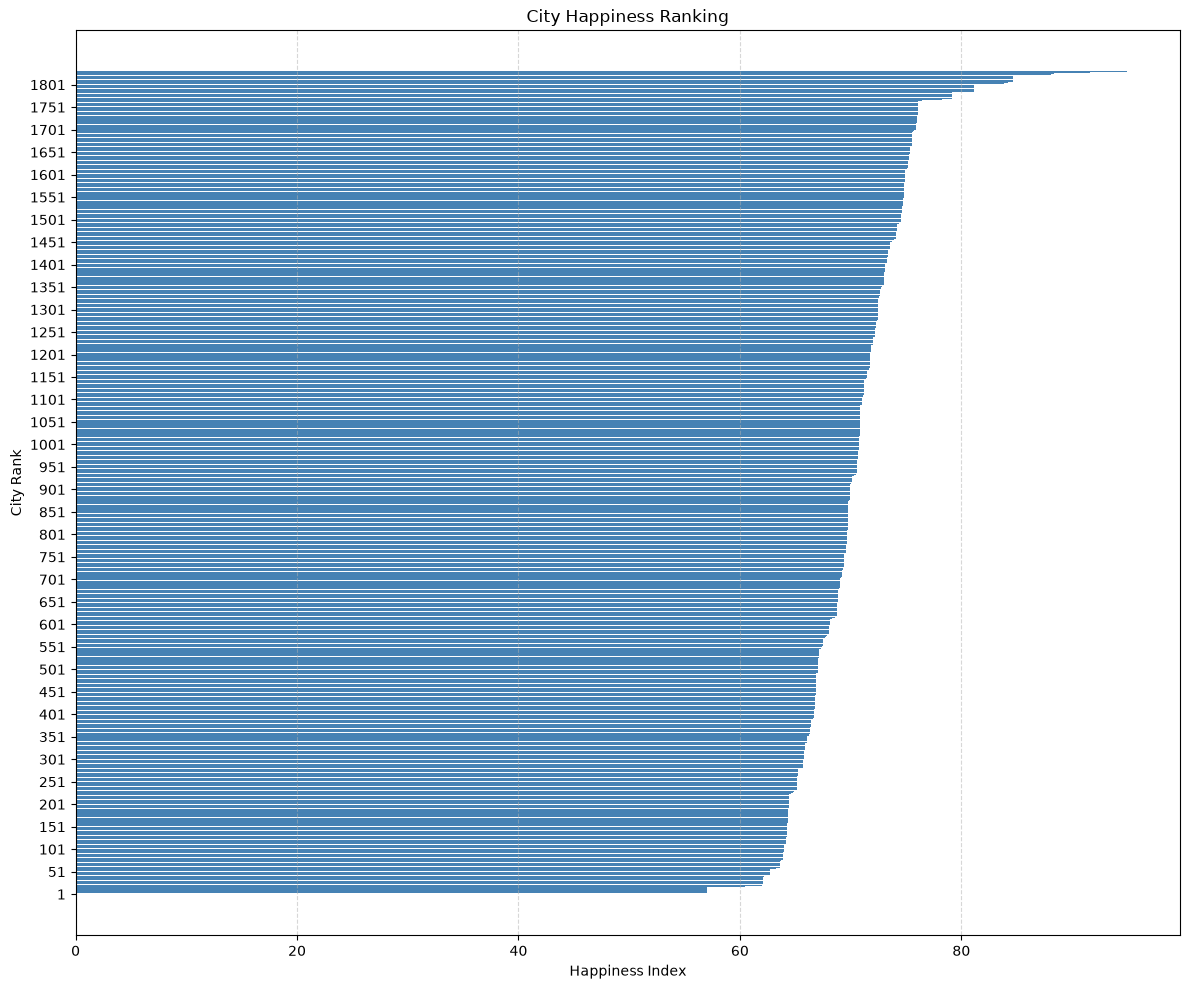

In [107]:
import matplotlib.pyplot as plt
#按幸福度排序
df_sorted = df.sort_values("happiness").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

ax.barh(range(len(df_sorted)), df_sorted["happiness"], color="steelblue")
#每50个城市显示一个刻度
step = 50
ticks = list(range(0, len(df_sorted), step))
ax.set_yticks(ticks)
ax.set_yticklabels([str(i + 1) for i in ticks])

ax.set_xlabel("Happiness Index")
ax.set_ylabel("City Rank")
ax.set_title("City Happiness Ranking")
ax.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

全国300个主要城市的收入与幸福度之间的散点图分布分析

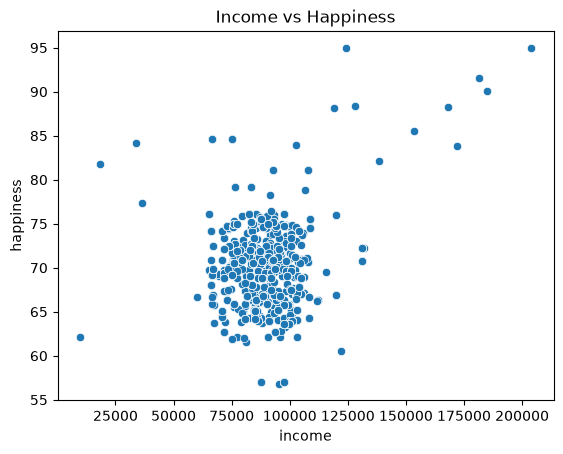

In [108]:
import seaborn as sns

sns.scatterplot(data=df, x="income", y="happiness")
plt.title("Income vs Happiness")
plt.show()

全国300个主要城市的房价与幸福度之间的散点图分布分析

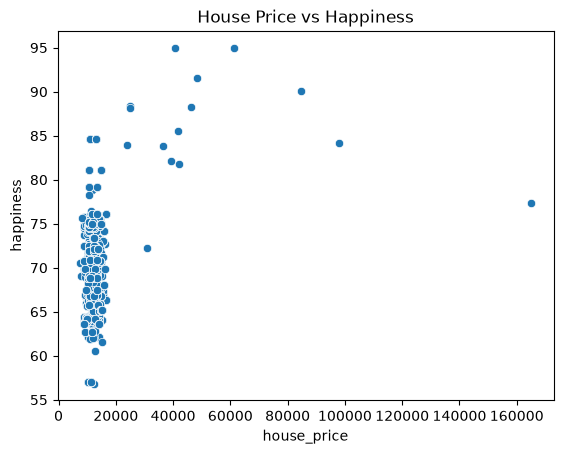

In [109]:
sns.scatterplot(data=df, x="house_price", y="happiness")
plt.title("House Price vs Happiness")
plt.show()

中国城市生活成本与幸福感分析的可视化宜居度地图

In [110]:
from pyecharts.charts import Map
from pyecharts import options as opts

# 按省份计算平均宜居度
prov_data = df.groupby('province')['happiness'].mean().reset_index()
# 生成地图数据项列表
map_data = list(zip(prov_data['province'], prov_data['happiness']))

# 创建 Map 实例并添加数据
m = Map()
m.add("宜居度", map_data, "china")

# 配置全局选项：标题和视觉映射组件（分段）
m.set_global_opts(
    title_opts=opts.TitleOpts(title="中国各省市宜居度地图"),
    visualmap_opts=opts.VisualMapOpts(
        min_=prov_data['happiness'].min(),
        max_=prov_data['happiness'].max(),
        is_piecewise=True,  # 分段式视觉映射
        pieces=[
            {"min": 90, "label": "极高"},
            {"min": 80, "max": 90, "label": "较高"},
            {"min": 70, "max": 80, "label": "中等"},
            {"max": 70, "label": "较低"},
        ]
    ),

    tooltip_opts=opts.TooltipOpts(formatter="省市:{b}<br>宜居度:{c}")
)
# 不显示地图上每个省的标签
m.set_series_opts(label_opts=opts.LabelOpts(is_show=False))
# 渲染HTML文件
m.render("中国各省市宜居度地图.html")


'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\中国各省市宜居度地图.html'

In [111]:
from pyecharts.charts import Geo
from pyecharts import options as opts
from pyecharts.globals import ChartType

geo = Geo()

#添加地图
geo.add_schema(
    maptype="china"
)

# 添加城市坐标
for city, coord in location.items():
    geo.add_coordinate(
        city,
        coord[0],
        coord[1]
    )

# Top50城市
top50 = (
    df.sort_values(
        "value_index",
        ascending=False
    )
    .head(50)
)

geo_data = []

for _, row in top50.iterrows():
    if row["city"] in location:
        geo_data.append(
            (
                row["city"],
                row["value_index"]
            )
        )

print("气泡数量:", len(geo_data))

geo.add(
    "城市价值指数",
    geo_data,
    type_=ChartType.EFFECT_SCATTER,
    symbol_size=15
)

geo.set_global_opts(
    title_opts=opts.TitleOpts(
        title="中国城市生活价值指数分布"
    ),
    visualmap_opts=opts.VisualMapOpts(
        min_=df["value_index"].min(),
        max_=df["value_index"].max()
    )
)

geo.set_series_opts(
    label_opts=opts.LabelOpts(
        is_show=False
    )
)

geo.render(
    "中国城市生活价值指数分布.html"
)

气泡数量: 0


'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\中国城市生活价值指数分布.html'